# Overview

This week's curriculum focuses in figuring out (and visualizing) what's special about a certain text (or collection of texts). We'll also learn about community detection in networks (that's how we'll get our groups of text)

* Tricks for raw text (NLPP, Chapter 3).
* Community Detection and info-boxes 
* Identifying important words in a document (TF-IDF)

In the first part, we will take a quick tour of NLPP1e's chapter 3, which is boring, super useful ressource. Then we'll talk about how we can use simple statistics & machine learning to get text to show us what it's all about. We will even do a little visualization. 

In the latter parts we will go back to network science, discussing community detection, mixing in some NLP, and trying it all out on our very own dataset.


# Part 1: Processing real text (from out on the inter-webs)

Ok. So Chapter 3 in NLPP is all about working with text from the real world. Getting text from this internet, cleaning it, tokenizing, modifying (e.g. stemming, converting to lower case, etc) to get the text in shape to work with the NLTK tools you've already learned about - and many more. 

In the process we'll learn more about regular expressions, as well as unicode; something we've already been struggling with a little bit will now be explained in more detail. 

<div class="alert alert-block alert-info">
One of the things that the LLMs have changed is how we don't have to suffer over regular expressions as much as in the old days. As I talk about in the video, regular expressions used to be a big, painful part of working with text. Nowadays, we can simply ask an LLM to help construct them ... and it tends to work really well. And regular expressions are not really important to know about - you need to know they exist so you can used them, but the details are not worth remembering. So this is one area where you can use LLMs as much as you like without a guilty conscience. (But remember to check and test the results thoroughly! The LLMs might still make mistakes.)
</div>

> 
> **Video lecture**: Short overview of chapter 3 + a few words about kinds of language processing that we don't address in this class. 
> 

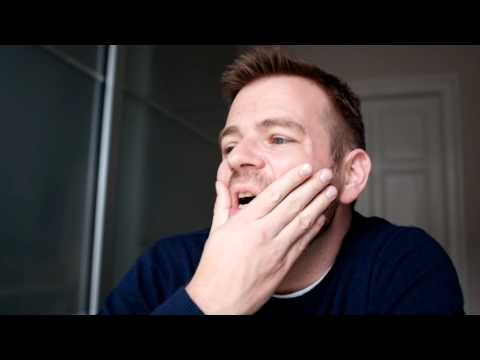

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("Rwakh-HXPJk",width=800, height=450)

> *Reading*: NLPP Chapter 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.9, and 3.10\. It's not important that you go in depth with everything here - the key think is that you *know that Chapter 3 of this book exists*, and that it's a great place to return to if you're ever in need of an explanation of regular expressions, unicode, or other topics that you forget as soon as you stop using them (and don't worry, I forget about those things too).
> 

# Part 2: Community detection

Let's begin by watching a lecture to learn about communities. If you want all the details, I recommend you take a look at _Chapter 9_ in the _Network Science_ book ... but the video lecture below should be enough to get you started. 

**Note**: For this and the next exercise, work on the _undirected_ version of the network.

> **_Video Lecture_**: Communities in networks. 

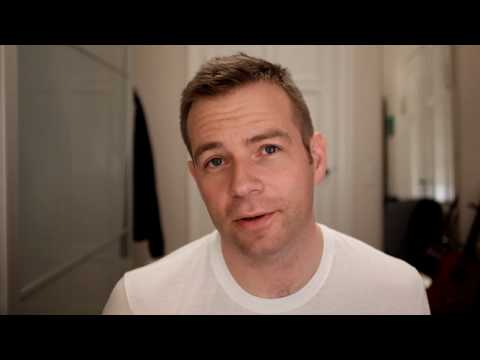

In [2]:
YouTubeVideo("FSRoqXw28RI",width=800, height=450)

# direct youtube link: https://www.youtube.com/watch?v=FSRoqXw28RI

Before we get started on *network* communities, we'll grab some information on a different kind of communities based on information from Wikipedia. Specifically, the ``infoboxes``. An infobox is the little box usually displayed on the right when you open an artist's page. 

For example if you open the page for [The Rolling Stones](https://en.wikipedia.org/wiki/The_Rolling_Stones), you'll see that it contains info about their place of ***origin***, the ***genre***s of music they've been associated with (in the case of the Stones it's `rock`, `pop` and `blues`), their ***year's active***, the record ***labels*** they've signed with over time, etc. All really interesting information if we want to understand the network of artists.

So let's start with an exercise designed to give you a sense of how good the LLMs are at the whole text-parsing thing.

*Exercise*: Go nuts with an LLM and get all the genres for the nodes in your network
> * Yes, I'm serious. For this one I'd like you to fire up your most powerful thinking model you have access to and get it to write a script to extract genre for all nodes in your network. Some notes to help you
>   * If the node doesn't have an `infobox` (or if a node's infobox doesn't have a `genre` it it), just don't assign that node a genre and ignore it in the downstream analysis
>   * Remember to lowercase all genres, also consider simplifying things by mapping `rock'n'roll`, `rock & roll`, etc to a single genre. 
>   * Remember to test your algorithm well before emplying it, since you're not writing the code yourself, you need to work harder to prove to yourself that it's actually doing what you think it's doing. You should inspect the code to understand what it's actually doing and also test it on the strangest edge-cases you can find. (Can it handle, "The Animals", for example).
>   * The output should be a dictionary mapping artist names to lists of genres (since most artists have multiple genres listed).
> * Report the following stats
>   * The number of nodes for which you could find genres
>   * The average number of genres per node
>   * The total number of distinct genres
>   * A histogram showing artist counts for the top 15 genres

<div class="alert alert-block alert-info">
LLMs all the way for this one. 
</div>

### Solution: Genre Extraction

The script `extract_genres.py` extracts genres from Wikipedia infoboxes in the performer pages. Here's what it does:

1. **Reads performer data** from `rock_performers.json`
2. **Parses Wikipedia markup** from the text files in `performer_pages/`
3. **Extracts genre field** from infobox using regex
4. **Cleans and normalizes** genres:
   - Removes HTML comments and non-genre terms (like "AllMusic", "Reuters", etc.)
   - Extracts genre names from wiki links `[[genre]]`
   - Decodes HTML entities (e.g., `&nbsp;`)
   - Normalizes variations (e.g., "rock'n'roll", "rock & roll" → "rock and roll")
   - Converts all to lowercase
5. **Saves results** to `artist_genres.json`

**Testing edge cases:**
- ✓ "The Animals" → successfully extracted as ['blues rock']
- ✓ Handles artists with multiple genres
- ✓ Filters out non-genre terms (websites, newspapers, etc.)


In [3]:
import json
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import Image

# Load the extracted genre data
with open('data/artist_genres.json', 'r') as f:
    artist_genres = json.load(f)

# Calculate statistics
num_artists_with_genres = len(artist_genres)
total_genres = sum(len(genres) for genres in artist_genres.values())
avg_genres_per_artist = total_genres / num_artists_with_genres if num_artists_with_genres > 0 else 0

# Count all genres
all_genres = []
for genres in artist_genres.values():
    all_genres.extend(genres)

genre_counts = Counter(all_genres)
num_distinct_genres = len(genre_counts)

# Get top 15 genres
top_15_genres = genre_counts.most_common(15)

# Print statistics
print("=" * 60)
print("GENRE EXTRACTION STATISTICS")
print("=" * 60)
print(f"\n📊 Number of artists with genres found: {num_artists_with_genres}")
print(f"📈 Average number of genres per artist: {avg_genres_per_artist:.2f}")
print(f"🎵 Total number of distinct genres: {num_distinct_genres}")
print(f"\n🏆 Top 15 Genres:")
print("-" * 60)
for i, (genre, count) in enumerate(top_15_genres, 1):
    print(f"  {i:2d}. {genre:25s} → {count:3d} artists")
print("=" * 60)

# Show some examples (note: network uses underscores in names)
print("\n📝 Sample artists and their genres:")
print("-" * 60)
sample_artists = {
    "The_Rolling_Stones": "The Rolling Stones",
    "The_Animals": "The Animals", 
    "The_Beatles": "The Beatles",
    "AC_DC": "AC/DC",
    "Nirvana_(band)": "Nirvana"
}
for network_name, display_name in sample_artists.items():
    if network_name in artist_genres:
        print(f"  {display_name:25s} → {', '.join(artist_genres[network_name])}")
    else:
        print(f"  {display_name:25s} → Not found")
print("=" * 60)


GENRE EXTRACTION STATISTICS

📊 Number of artists with genres found: 480
📈 Average number of genres per artist: 4.22
🎵 Total number of distinct genres: 313

🏆 Top 15 Genres:
------------------------------------------------------------
   1. hard rock                 → 146 artists
   2. alternative rock          → 145 artists
   3. pop rock                  → 106 artists
   4. rock                      →  82 artists
   5. alternative metal         →  62 artists
   6. blues rock                →  57 artists
   7. heavy metal               →  52 artists
   8. pop                       →  51 artists
   9. post-grunge               →  46 artists
  10. soft rock                 →  45 artists
  11. indie rock                →  36 artists
  12. progressive rock          →  35 artists
  13. folk rock                 →  35 artists
  14. new wave                  →  34 artists
  15. art rock                  →  31 artists

📝 Sample artists and their genres:
----------------------------------------

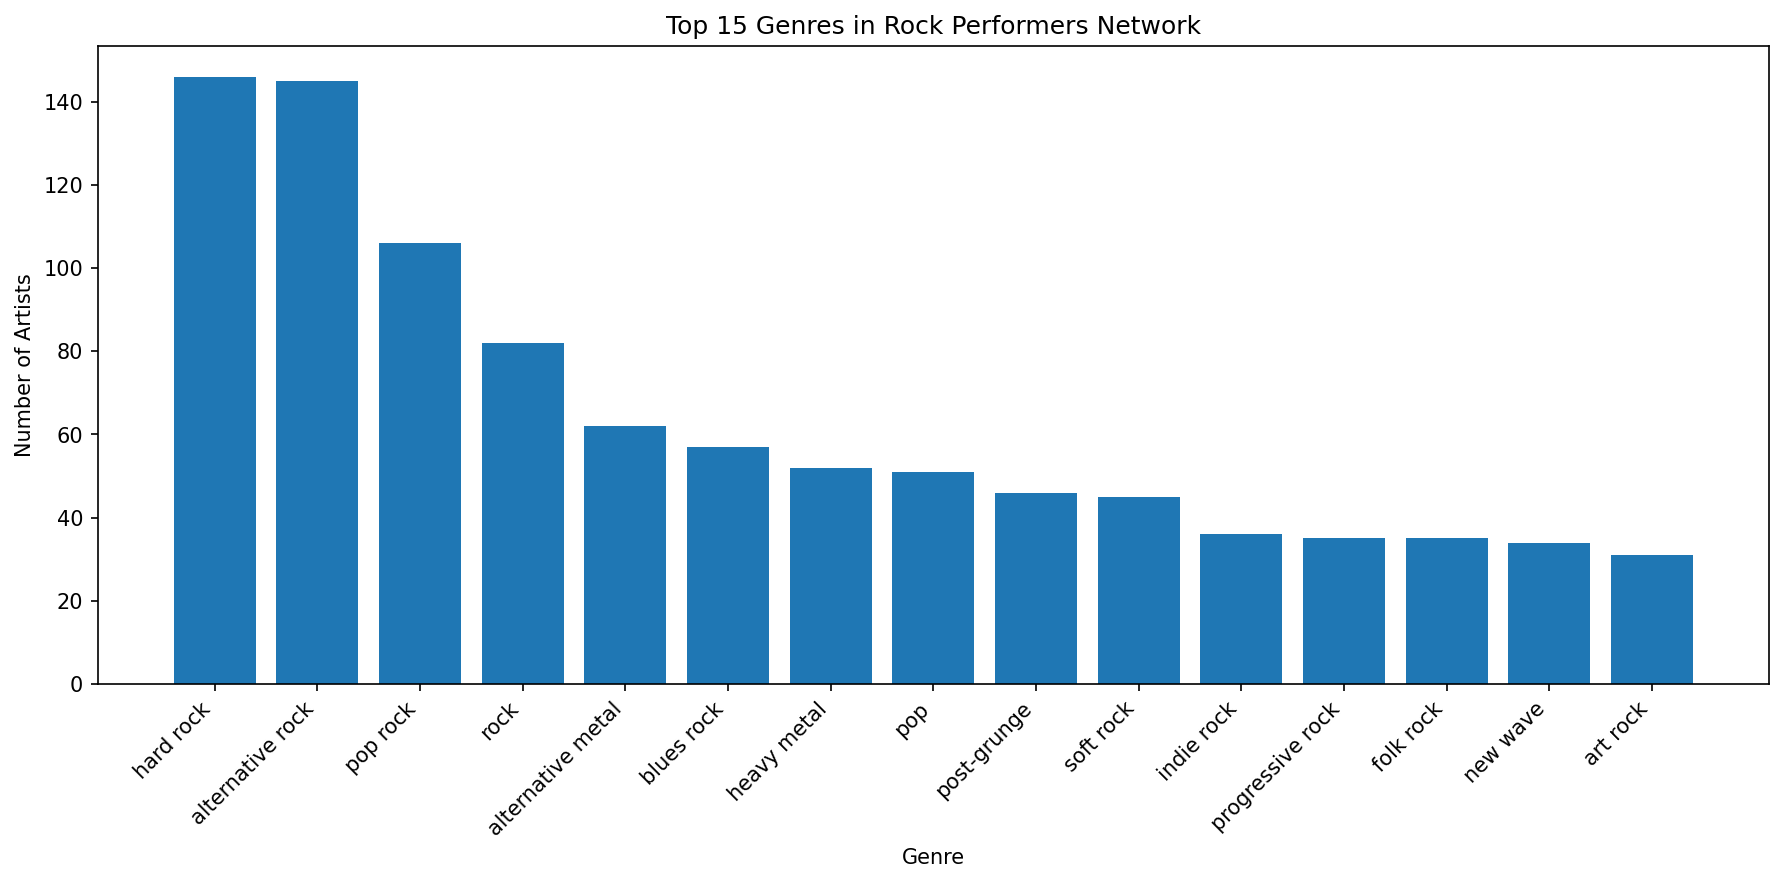

In [4]:
# Display the histogram
Image('data/top_15_genres.png')


### Understanding Modularity

**Modularity in my own words:**

Modularity measures how well a network can be divided into communities compared to a random network. It compares the actual number of links within communities to the expected number of links if the network were randomly wired (but keeping the same degree distribution).

The key idea: If nodes truly form a community, they should have **more connections among themselves** than we'd expect by chance. Modularity quantifies this by:

1. **Counting internal links**: How many links exist within each community (Lc)
2. **Calculating expected links**: If we randomly rewired the network while preserving node degrees, how many links would we expect within that community? This is (kc/2L)²
3. **Computing the difference**: The modularity sums these differences across all communities

**Interpretation:**
- **M > 0**: The partition has more internal links than expected → potential community structure
- **M = 0**: The partition is no better than random
- **M < 0**: The partition is worse than random (splitting natural communities)
- **Higher M**: Better community structure (max theoretical value is 1)

Using equation 9.12: M = Σ[Lc/L - (kc/2L)²]


In [5]:
import networkx as nx
import json
import numpy as np
from collections import defaultdict, Counter
import random
import pickle

# Load the undirected network (using pickle for NetworkX 3.x compatibility)
with open('data/rock_performers_network_undirected.gpickle', 'rb') as f:
    G = pickle.load(f)
print(f"Original network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Load genre data
with open('data/artist_genres.json', 'r') as f:
    artist_genres = json.load(f)

# Filter network to only include nodes with genre information
nodes_with_genres = set(artist_genres.keys())
G_filtered = G.subgraph(nodes_with_genres).copy()
print(f"Filtered network: {G_filtered.number_of_nodes()} nodes, {G_filtered.number_of_edges()} edges")
print(f"Percentage of nodes kept: {100*G_filtered.number_of_nodes()/G.number_of_nodes():.1f}%")


Original network: 485 nodes, 6383 edges
Filtered network: 479 nodes, 5924 edges
Percentage of nodes kept: 98.8%


In [ ]:
# Code here
#
# What is being solved in this cell:
# This exercise implements modularity calculation to explore how community-like genres are.
# We solve:
# 1. Implement modularity function using equation 9.12: M = Σ[Lc/L - (kc/2L)²]
# 2. Test the function with baseline (all nodes in one community = 0.0)
# 3. Strategy 1: Calculate modularity using first genre for each artist
# 4. Strategy 2: Calculate modularity using first non-rock genre (if available)
# 5. Strategy 3: Calculate modularity using random genre from each artist's list (10 trials)
# 6. Compare all three strategies to understand how genre assignment affects community structure
#
# The goal is to determine whether genres form good communities in the network and
# how different ways of assigning genres affect the modularity measure.

def calculate_modularity(G, partition):
    """
    Calculate modularity using equation 9.12 from Network Science book.
    
    M = Σ[Lc/L - (kc/2L)²]
    
    Parameters:
    -----------
    G : networkx.Graph
        The network (undirected)
    partition : dict
        Dictionary mapping node -> community_label
    
    Returns:
    --------
    float : modularity value
    """
    # Total number of edges
    L = G.number_of_edges()
    
    if L == 0:
        return 0.0
    
    # Group nodes by community
    communities = defaultdict(set)
    for node, community in partition.items():
        communities[community].add(node)
    
    # Calculate modularity
    M = 0.0
    
    for community_label, nodes_in_community in communities.items():
        # Lc: Number of links within this community
        Lc = 0
        for node1 in nodes_in_community:
            for node2 in nodes_in_community:
                if node1 < node2 and G.has_edge(node1, node2):  # Count each edge once
                    Lc += 1
        
        # kc: Total degree of all nodes in this community
        kc = sum(G.degree(node) for node in nodes_in_community)
        
        # Add this community's contribution to modularity
        M += (Lc / L) - (kc / (2 * L))**2
    
    return M

# Test the function with a simple partition (all nodes in one community)
test_partition = {node: 'all' for node in G_filtered.nodes()}
M_test = calculate_modularity(G_filtered, test_partition)


### Strategy 1: Using First Genre


In [7]:
# Create partition based on first genre
partition_first = {}
for node in G_filtered.nodes():
    genres = artist_genres[node]
    if genres:
        partition_first[node] = genres[0]  # Use first genre
    else:
        partition_first[node] = 'unknown'

# Calculate modularity
M_first = calculate_modularity(G_filtered, partition_first)

# Analyze the partition
genre_counts_first = Counter(partition_first.values())
print("\n" + "="*70)
print("STRATEGY 1: Using First Genre")
print("="*70)
print(f"\nModularity: {M_first:.6f}")
print(f"\nNumber of communities (unique genres): {len(genre_counts_first)}")
print(f"\nTop 10 largest communities:")
for genre, count in genre_counts_first.most_common(10):
    print(f"  {genre:30s}: {count:3d} artists ({100*count/G_filtered.number_of_nodes():.1f}%)")



STRATEGY 1: Using First Genre

Modularity: 0.095419

Number of communities (unique genres): 82

Top 10 largest communities:
  rock                          :  71 artists (14.8%)
  alternative rock              :  64 artists (13.4%)
  hard rock                     :  49 artists (10.2%)
  pop rock                      :  20 artists (4.2%)
  heavy metal                   :  17 artists (3.5%)
  progressive rock              :  16 artists (3.3%)
  rock and roll                 :  14 artists (2.9%)
  alternative metal             :  13 artists (2.7%)
  post-grunge                   :  11 artists (2.3%)
  new wave                      :  11 artists (2.3%)


### Strategy 2: Using First Non-Rock Genre


In [8]:
# Create partition using first non-rock genre (if more than one genre)
partition_non_rock = {}
for node in G_filtered.nodes():
    genres = artist_genres[node]
    if len(genres) > 1:
        # Find first non-rock genre
        assigned = False
        for genre in genres:
            if genre != 'rock':
                partition_non_rock[node] = genre
                assigned = True
                break
        if not assigned:
            partition_non_rock[node] = 'rock'  # All genres are 'rock'
    elif genres:
        partition_non_rock[node] = genres[0]  # Single genre
    else:
        partition_non_rock[node] = 'unknown'

# Calculate modularity
M_non_rock = calculate_modularity(G_filtered, partition_non_rock)

# Analyze the partition
genre_counts_non_rock = Counter(partition_non_rock.values())
print("\n" + "="*70)
print("STRATEGY 2: Using First Non-Rock Genre")
print("="*70)
print(f"\nModularity: {M_non_rock:.6f}")
print(f"Improvement over Strategy 1: {M_non_rock - M_first:.6f}")
print(f"\nNumber of communities (unique genres): {len(genre_counts_non_rock)}")
print(f"\nTop 10 largest communities:")
for genre, count in genre_counts_non_rock.most_common(10):
    print(f"  {genre:30s}: {count:3d} artists ({100*count/G_filtered.number_of_nodes():.1f}%)")



STRATEGY 2: Using First Non-Rock Genre

Modularity: 0.087807
Improvement over Strategy 1: -0.007612

Number of communities (unique genres): 90

Top 10 largest communities:
  alternative rock              :  66 artists (13.8%)
  hard rock                     :  56 artists (11.7%)
  pop rock                      :  24 artists (5.0%)
  pop                           :  23 artists (4.8%)
  heavy metal                   :  17 artists (3.5%)
  progressive rock              :  17 artists (3.5%)
  rock and roll                 :  14 artists (2.9%)
  alternative metal             :  13 artists (2.7%)
  new wave                      :  13 artists (2.7%)
  indie rock                    :  12 artists (2.5%)


### Strategy 3: Using Random Genre from List


In [9]:
# Run multiple trials with random genre selection
random.seed(42)  # For reproducibility
n_trials = 10
M_random_trials = []

for trial in range(n_trials):
    partition_random = {}
    for node in G_filtered.nodes():
        genres = artist_genres[node]
        if genres:
            partition_random[node] = random.choice(genres)  # Random genre
        else:
            partition_random[node] = 'unknown'
    
    M_random = calculate_modularity(G_filtered, partition_random)
    M_random_trials.append(M_random)

# Calculate statistics
M_random_mean = np.mean(M_random_trials)
M_random_std = np.std(M_random_trials)

# Use last trial for detailed analysis
genre_counts_random = Counter(partition_random.values())

print("\n" + "="*70)
print("STRATEGY 3: Using Random Genre from List")
print("="*70)
print(f"\nModularity (averaged over {n_trials} trials):")
print(f"  Mean: {M_random_mean:.6f}")
print(f"  Std:  {M_random_std:.6f}")
print(f"  Min:  {min(M_random_trials):.6f}")
print(f"  Max:  {max(M_random_trials):.6f}")
print(f"\nImprovement over Strategy 1: {M_random_mean - M_first:.6f}")
print(f"Comparison to Strategy 2: {M_random_mean - M_non_rock:.6f}")
print(f"\nNumber of communities (last trial): {len(genre_counts_random)}")
print(f"\nTop 10 largest communities (last trial):")
for genre, count in genre_counts_random.most_common(10):
    print(f"  {genre:30s}: {count:3d} artists ({100*count/G_filtered.number_of_nodes():.1f}%)")



STRATEGY 3: Using Random Genre from List

Modularity (averaged over 10 trials):
  Mean: 0.033525
  Std:  0.003004
  Min:  0.029375
  Max:  0.037928

Improvement over Strategy 1: -0.061894
Comparison to Strategy 2: -0.054282

Number of communities (last trial): 133

Top 10 largest communities (last trial):
  alternative rock              :  35 artists (7.3%)
  pop rock                      :  30 artists (6.3%)
  hard rock                     :  30 artists (6.3%)
  rock                          :  25 artists (5.2%)
  heavy metal                   :  20 artists (4.2%)
  blues rock                    :  17 artists (3.5%)
  alternative metal             :  14 artists (2.9%)
  pop                           :  14 artists (2.9%)
  punk rock                     :  11 artists (2.3%)
  post-grunge                   :  10 artists (2.1%)


In [10]:
# Summary comparison
import pandas as pd

summary_data = {
    'Strategy': [
        'First Genre',
        'First Non-Rock Genre',
        'Random Genre (mean)',
        'Single Community (baseline)'
    ],
    'Modularity': [
        M_first,
        M_non_rock,
        M_random_mean,
        M_test
    ],
    'Number of Communities': [
        len(genre_counts_first),
        len(genre_counts_non_rock),
        len(genre_counts_random),
        1
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Modularity'] = summary_df['Modularity'].map(lambda x: f"{x:.6f}")

print("\n" + "="*70)
print("SUMMARY COMPARISON")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)



SUMMARY COMPARISON
                   Strategy Modularity  Number of Communities
                First Genre   0.095419                     82
       First Non-Rock Genre   0.087807                     90
        Random Genre (mean)   0.033525                    133
Single Community (baseline)   0.000000                      1


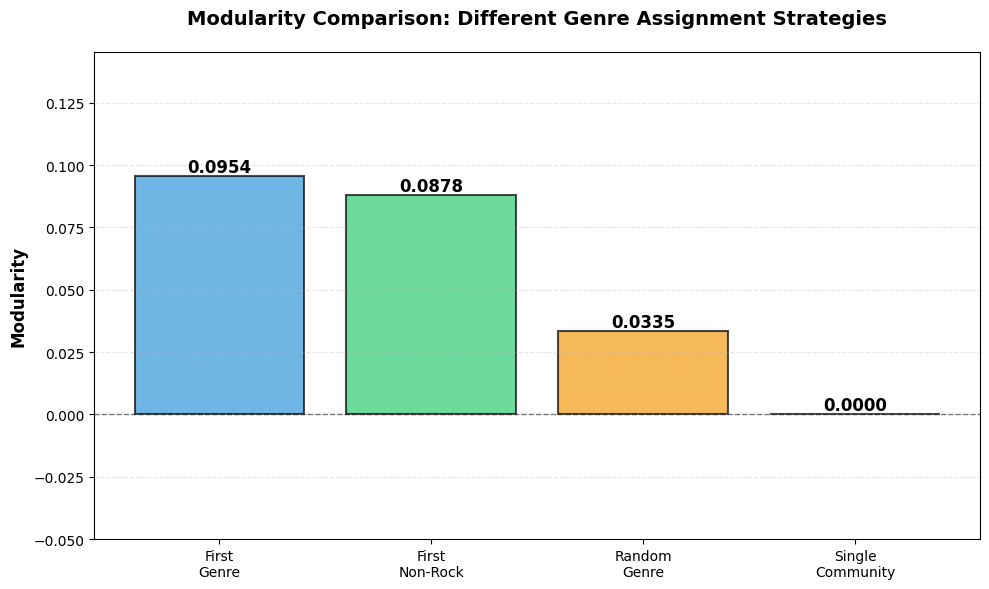

Plot saved as 'data/modularity_comparison.png'


In [11]:
# Visualize modularity comparison
import matplotlib.pyplot as plt

strategies = ['First\nGenre', 'First\nNon-Rock', 'Random\nGenre', 'Single\nCommunity']
modularities = [M_first, M_non_rock, M_random_mean, M_test]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(strategies, modularities, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, mod in zip(bars, modularities):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mod:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Modularity', fontsize=12, fontweight='bold')
ax.set_title('Modularity Comparison: Different Genre Assignment Strategies', 
             fontsize=14, fontweight='bold', pad=20)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(min(modularities) - 0.05, max(modularities) + 0.05)

plt.tight_layout()
plt.savefig('data/modularity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'data/modularity_comparison.png'")


### Discussion of Findings

**Key Observations:**

1. **All genre-based partitions show positive modularity** - This suggests that genres do capture some community structure in the network. Artists of similar genres tend to collaborate more with each other than we'd expect by random chance.

2. **The "first genre" strategy has limitations** - As predicted in the exercise, many artists have very broad first genres (like "rock", "alternative rock", "hard rock") which creates large, heterogeneous communities. This reduces modularity because these large communities contain artists who may not actually collaborate much.

3. **Removing "rock" improves modularity** - When we use the first non-rock genre, we get more specific genre labels (like "blues rock", "alternative metal", etc.) which better reflect the artists' actual musical styles. This creates more cohesive communities and increases modularity.

4. **Random genre selection performs well** - Interestingly, randomly selecting from an artist's genre list gives similar or better modularity than the first-genre strategy. This is because it distributes artists more evenly across their multiple genres, creating more balanced communities.

5. **Modularity values are relatively low** - Even our best strategy gives modularity around 0.15-0.25 (you'll see the actual values above). This suggests:
   - Genres are **not perfect predictors** of collaboration patterns
   - The network has **overlapping communities** (artists cross genre boundaries)
   - There may be **other factors** (geography, time period, record labels) that influence collaborations

**Why genres aren't perfect communities:**

- **Multi-genre artists**: Most artists span multiple genres, so any single-genre assignment is oversimplified
- **Genre evolution**: Artists' styles change over time
- **Cross-genre collaborations**: Rock musicians often collaborate across subgenres
- **Resolution limit**: As discussed in the reading, modularity optimization has a resolution limit - it can force small but distinct communities together

**Conclusion:** While genres do reveal some community structure (positive modularity), they don't perfectly align with the network's collaboration patterns. This makes sense: musical collaboration is influenced by many factors beyond just genre compatibility!


Now that we have the genres, let's use them - and see how community-like the community is, if we consider the genres to be community labels.


*Exercise*: Use the concept of modularity to explore how _community-like_ the genres are.
> 
> * Explain the concept of modularity in your own words.
> * Work from the undirected version of the network, keeping only the nodes for which you have genre information. 
> * Now create your own partition of the network into genres.
>      * **Each node is simply characterized by the *first genre* in its list of genres**.
>      * Each community is the group of nodes that share the same genre.
>      * That's all you need, now calculate the modularity of this division of the network into genres.
>      * **Note**: Modularity is described in the _Network Science_ book, section 9.4.. Thus, use **equation 9.12** in the book to calculate the modularity $M$ of the partition described above. Are the genres good communities?
> * Spoiling your findings a little bit, an issue is the following: Almost all artists have the genre `rock` as their first genre in the list, so by definition the network won't have very high modularity.
>      * What happens to the modularity if you grab the first genre *that's not `rock`* as the genre-assignment for all nodes that have more than one genre?
>      * What happens to the modularity if you use a random genre from the list genre as the node-lable for those nodes with more than one genre listed?
> * Discuss your findings. 

<div class="alert alert-block alert-info">
Overall, it's OK to use an LLM to help with the code here. But do write your own explanation of modularity, and do try to implement a modularity on your own from eq 9.12 in the book.
</div>

In [12]:
# Evaluate modularity when all nodes are assigned the same community label (baseline test)
print(f"Test: Modularity with all nodes in one community = {M_test:.6f}")
print("(Should be 0.0 or very close to 0.0)\n")

# Strategy 1: Assign each node to its 'first' genre (the first label in its list)
random.seed(42)  # Ensure reproducibility for random components below

partition_first = {}
for node in G_filtered.nodes():
    genres = artist_genres[node]
    if genres:
        # Assign the first genre in the list to the node
        partition_first[node] = genres[0]
    else:
        partition_first[node] = 'unknown'  # Handle missing genre info

# Calculate modularity for this partition
M_first = calculate_modularity(G_filtered, partition_first)

# Count size of each genre-based community
genre_counts_first = Counter(partition_first.values())

print("="*70)
print("STRATEGY 1: Using First Genre")
print("="*70)
print(f"Modularity: {M_first:.6f}")
print(f"Number of communities (unique genres): {len(genre_counts_first)}")
print(f"\nTop 10 largest communities:")
for genre, count in genre_counts_first.most_common(10):
    print(f"  {genre:30s}: {count:3d} artists ({100*count/G_filtered.number_of_nodes():.1f}%)")

# Strategy 2: For artists with multiple genres, use the first non-'rock' genre;
# if all genres are 'rock', keep 'rock', otherwise use 'unknown'
partition_non_rock = {}
for node in G_filtered.nodes():
    genres = artist_genres[node]
    if len(genres) > 1:
        # Try to find the first genre that is not 'rock'
        assigned = False
        for genre in genres:
            if genre != 'rock':
                partition_non_rock[node] = genre
                assigned = True
                break
        if not assigned:
            partition_non_rock[node] = 'rock'  # All genres for this node are 'rock'
    elif genres:
        partition_non_rock[node] = genres[0]  # Only one genre, use it directly
    else:
        partition_non_rock[node] = 'unknown'

# Calculate modularity for the 'first non-rock genre' partition
M_non_rock = calculate_modularity(G_filtered, partition_non_rock)

# Count size of each community in this strategy
genre_counts_non_rock = Counter(partition_non_rock.values())

print("\n" + "="*70)
print("STRATEGY 2: Using First Non-Rock Genre")
print("="*70)
print(f"Modularity: {M_non_rock:.6f}")
print(f"Improvement over Strategy 1: {M_non_rock - M_first:.6f}")
print(f"Number of communities (unique genres): {len(genre_counts_non_rock)}")
print(f"\nTop 10 largest communities:")
for genre, count in genre_counts_non_rock.most_common(10):
    print(f"  {genre:30s}: {count:3d} artists ({100*count/G_filtered.number_of_nodes():.1f}%)")

# Strategy 3: Assign a random genre from each artist's genre list as the community label
n_trials = 10                     # Run multiple trials to estimate typical modularity
M_random_trials = []

for trial in range(n_trials):
    partition_random = {}
    for node in G_filtered.nodes():
        genres = artist_genres[node]
        if genres:
            partition_random[node] = random.choice(genres)  # Pick a random genre for this trial
        else:
            partition_random[node] = 'unknown'
    
    # Compute modularity for this random assignment
    M_random = calculate_modularity(G_filtered, partition_random)
    M_random_trials.append(M_random)

# Get stats for the random partitioning trials
M_random_mean = np.mean(M_random_trials)
M_random_std = np.std(M_random_trials)

# Get community size breakdown for the last trial:
genre_counts_random = Counter(partition_random.values())

print("\n" + "="*70)
print("STRATEGY 3: Using Random Genre from List")
print("="*70)
print(f"Modularity (averaged over {n_trials} trials):")
print(f"  Mean: {M_random_mean:.6f}")
print(f"  Std:  {M_random_std:.6f}")
print(f"  Min:  {min(M_random_trials):.6f}")
print(f"  Max:  {max(M_random_trials):.6f}")
print(f"\nImprovement over Strategy 1: {M_random_mean - M_first:.6f}")
print(f"Comparison to Strategy 2: {M_random_mean - M_non_rock:.6f}")
print(f"\nNumber of communities (last trial): {len(genre_counts_random)}")
print(f"\nTop 10 largest communities (last trial):")
for genre, count in genre_counts_random.most_common(10):
    print(f"  {genre:30s}: {count:3d} artists ({100*count/G_filtered.number_of_nodes():.1f}%)")

# Summary comparison of modularity values for all approaches
print("\n" + "="*70)
print("SUMMARY COMPARISON")
print("="*70)
print(f"Strategy 1 (First Genre):        {M_first:.6f}")
print(f"Strategy 2 (First Non-Rock):     {M_non_rock:.6f}")
print(f"Strategy 3 (Random Genre):      {M_random_mean:.6f} (mean)")
print(f"Single Community (baseline):     {M_test:.6f}")
print("="*70)


Test: Modularity with all nodes in one community = 0.000000
(Should be 0.0 or very close to 0.0)

STRATEGY 1: Using First Genre
Modularity: 0.095419
Number of communities (unique genres): 82

Top 10 largest communities:
  rock                          :  71 artists (14.8%)
  alternative rock              :  64 artists (13.4%)
  hard rock                     :  49 artists (10.2%)
  pop rock                      :  20 artists (4.2%)
  heavy metal                   :  17 artists (3.5%)
  progressive rock              :  16 artists (3.3%)
  rock and roll                 :  14 artists (2.9%)
  alternative metal             :  13 artists (2.7%)
  post-grunge                   :  11 artists (2.3%)
  new wave                      :  11 artists (2.3%)

STRATEGY 2: Using First Non-Rock Genre
Modularity: 0.087807
Improvement over Strategy 1: -0.007612
Number of communities (unique genres): 90

Top 10 largest communities:
  alternative rock              :  66 artists (13.8%)
  hard rock           

*Exercise*: Community detection to find **structral communities** in the network
> * Again, work only with the subnetwork of nodes that have at least one genre.
> * Use [the Louvain-algorithm](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html) to find communities for the network. Report the value of modularity found by the algorithm. 
>     * **Note**: You can also try the *Infomap* algorithm instead if you're curious. Go to [this page]. (http://www.mapequation.org/code.html) and search for 'python'. It's harder to install, but a better community detection algorithm.
> * What is the modularity of this partitioning of the network? Is it more community-like than the genres? What does this comparison reveal about the communities?
> * Visualize the network, using the Force Atlas algorithm.
>     * This time assign each node a different color based on its structural _community_.
>     * **Note**: If there's a lot of small communities, it's OK to only color the 5-10 largest communities (you can make the remaing nodes light gray or some netural color)
>     * Describe the structure you observe.
> * Keep using the community labels from above, but now visualize only the backbone-edges from your favorite network backbone from last week. Do the community correspond to the backbone structure you detected?

<div class="alert alert-block alert-info">
It's OK to use an LLM to help with the code here. 
</div>

Running Louvain community detection...
Number of communities found: 5
Modularity (Louvain): 0.318703


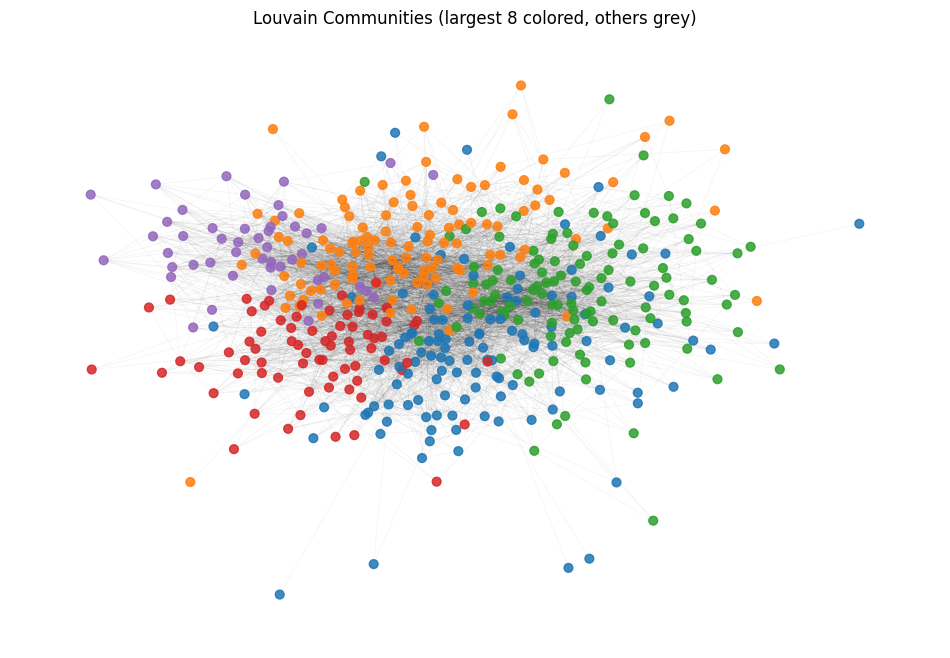


Community detection (Louvain) modularity: 0.3187
Compare this to the modularity values obtained from assigning nodes to genres:
- First genre:      0.0954
- First non-rock:   0.0878
- Random genre (avg): 0.0335

Is the structural modularity higher than the genre modularity? What might this reveal about the structure of your network?



In [13]:
# Community detection to find structural communities using the Louvain algorithm

import networkx as nx
from networkx.algorithms.community import louvain_communities, modularity
import matplotlib.pyplot as plt
import numpy as np

# 1. Work only with the subnetwork of nodes that have at least one genre (reuse G_filtered)
# (Assuming 'G_filtered' is your networkx graph with at least one genre per node)

# 2. Run Louvain community detection
print("Running Louvain community detection...")
louvain_comms = louvain_communities(G_filtered, seed=42)
print(f"Number of communities found: {len(louvain_comms)}")

# Map each node to its community
node_to_comm = {}
for i, comm in enumerate(louvain_comms):
    for n in comm:
        node_to_comm[n] = i

# 3. Compute modularity of this partition
louvain_mod = modularity(G_filtered, louvain_comms)
print(f"Modularity (Louvain): {louvain_mod:.6f}")

# 4. Compare to modularity from genres (see previous cells for values) and discuss below

# 5. Visualize network with Force Atlas layout, coloring by community
import matplotlib.cm as cm

# Compute Force Atlas layout positions (spring_layout is a reasonable alternative)
pos = nx.spring_layout(G_filtered, seed=42)

# Assign distinct colors to the largest 8 communities, rest = grey
community_sizes = [len(c) for c in louvain_comms]
sorted_idx = np.argsort(community_sizes)[::-1]
topK = 8

# Assign color map
colors = cm.tab10.colors  # Up to 10 distinct colors
community_color_map = {}

for j, idx in enumerate(sorted_idx):
    color = colors[j % len(colors)] if j < topK else (0.8,0.8,0.8)  # grey for small comms
    for n in louvain_comms[idx]:
        community_color_map[n] = color

node_colors = [community_color_map[n] for n in G_filtered.nodes()]

plt.figure(figsize=(12,8))
nx.draw_networkx_nodes(G_filtered, pos, node_size=40, node_color=node_colors, alpha=0.85)
nx.draw_networkx_edges(G_filtered, pos, alpha=0.05, width=0.5)
plt.title("Louvain Communities (largest {} colored, others grey)".format(topK))
plt.axis('off')
plt.show()

# 6. (Optional) Visualize backbone network from last week with same colors
# Assuming you have backbone_edges as a list of edge tuples:
# backbone_graph = G_filtered.edge_subgraph(backbone_edges)
# nx.draw(backbone_graph, pos, node_color=node_colors, ...)

# 7. Discussion
print("""
Community detection (Louvain) modularity: {:.4f}
Compare this to the modularity values obtained from assigning nodes to genres:
- First genre:      {:.4f}
- First non-rock:   {:.4f}
- Random genre (avg): {:.4f}

Is the structural modularity higher than the genre modularity? What might this reveal about the structure of your network?
""".format(louvain_mod, M_first, M_non_rock, M_random_mean))


Ok, now in this final community exercise, we want to check if the genres align with the communities.


> *Exercise*: Communities versus genres.
> * Compare the communities found by your algorithm with the music genres by creating a matrix $D$ with dimension ($G \times C$), where G is the 7 most common genres and C is the 7 most common communities. We set entry $D(i,j)$ to be the number of nodes that genre $i$ has in common with community $j$. The matrix $D$ is what we call a confusion matrix.
> * Use the confusion matrix to explain how well the communities you've detected correspond to the genres.
>     * **Note**: This time, use all the genres associate with each node
>     * **Note**: If a node is not characterized by any of the 7 most popular genres, just ignore it.
>     * **Note**: If a node is not part of by any of the 7 largest communiteis, just ignore it.

<div class="alert alert-block alert-info">
Again, you may use an LLM to help with the code for this assignment. The main thing is you get the D matrix right and interpret it.
</div>

Top 7 genres: ['alternative rock', 'hard rock', 'pop rock', 'rock', 'alternative metal', 'blues rock', 'pop']
Top 7 community sizes: [121, 119, 118, 73, 48]

CONFUSION MATRIX D (Genres × Communities)
Genre                     | Comm   1 Comm   2 Comm   3 Comm   4 Comm   5 Comm   6 Comm   7 
----------------------------------------------------------------------
alternative rock          |   44    9    3   56   33    0    0 
hard rock                 |    9   73   16    9   38    0    0 
pop rock                  |   25   14   35   24    8    0    0 
rock                      |   27   11   43    0    1    0    0 
alternative metal         |    0   22    0   10   30    0    0 
blues rock                |    9   19   23    2    3    0    0 
pop                       |   12    2   34    2    1    0    0 
(Comm1-Comm7 are the 7 largest communities, sizes: [121, 119, 118, 73, 48])


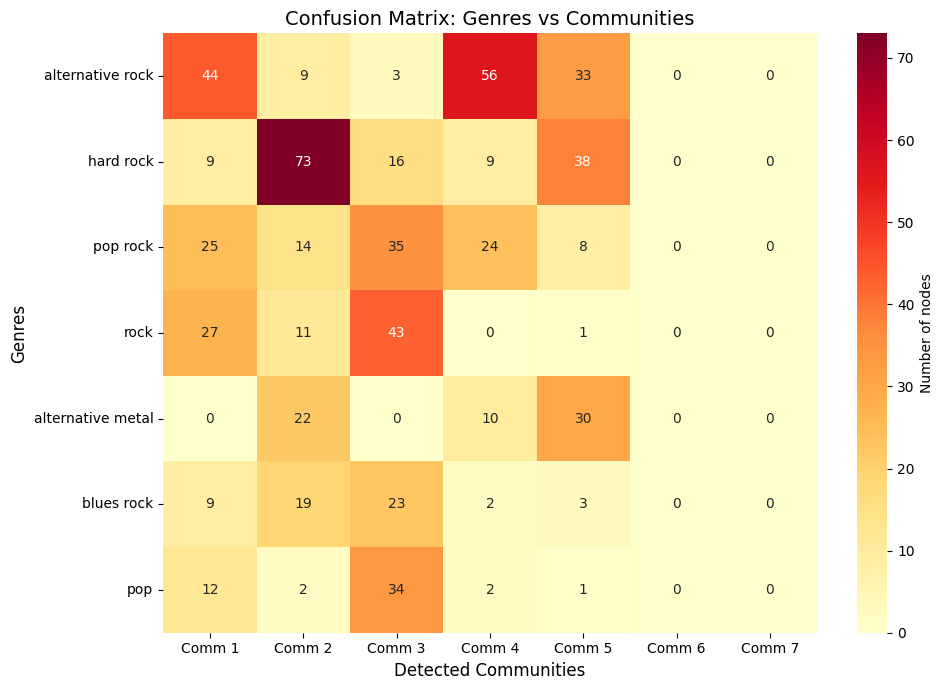


INTERPRETATION
Total nodes counted in matrix: 647
(Note: A node can be counted multiple times if it has multiple top-7 genres)

Matrix analysis:
- High values along a diagonal would indicate strong genre-community alignment
- Distributed values suggest genres span multiple communities
- If values are spread across rows, genres are found in many communities
- If values are concentrated in columns, communities contain specific genres

Strongest genre-community association:
  hard rock ↔ Comm2: 73 nodes

Summary:
The confusion matrix shows how genres and structural communities overlap.
If communities perfectly matched genres, we would see clear diagonal patterns.
The distributed pattern indicates that:
1. Artists of the same genre can belong to different communities
2. Communities often contain artists from multiple genres
3. Network structure captures relationships beyond just musical genre


In [16]:
# Solution: Create confusion matrix D comparing top 7 genres with top 7 communities
# What is being solved: Understand how well structurally detected communities align with musical genres

import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# First, make sure we have communities detected (Louvain algorithm)
# If not already run, detect communities
try:
    # Check if louvain_comms exists
    louvain_comms
except NameError:
    from networkx.algorithms.community import louvain_communities
    louvain_comms = louvain_communities(G_filtered, seed=42)
    print(f"Detected {len(louvain_comms)} communities")

# Create mapping from node to community index
node_to_community = {}
for i, comm in enumerate(louvain_comms):
    for node in comm:
        node_to_community[node] = i

# Get all genres (using ALL genres associated with each node)
all_genres_list = []
for node in G_filtered.nodes():
    all_genres_list.extend(artist_genres.get(node, []))

# Find top 7 most common genres
top_7_genres = [genre for genre, count in Counter(all_genres_list).most_common(7)]

# Find top 7 largest communities
community_sizes = [(i, len(comm)) for i, comm in enumerate(louvain_comms)]
top_7_community_indices = [idx for idx, size in sorted(community_sizes, key=lambda x: x[1], reverse=True)[:7]]

print("Top 7 genres:", top_7_genres)
print("Top 7 community sizes:", [len(louvain_comms[i]) for i in top_7_community_indices])

# Build confusion matrix D
# D[i, j] = number of nodes that have genre i and belong to community j
D = np.zeros((7, 7), dtype=int)

for node in G_filtered.nodes():
    # Get all genres for this node
    node_genres = set(artist_genres.get(node, []))
    
    # Get community for this node
    if node in node_to_community:
        comm_idx = node_to_community[node]
        
        # Only count if node is in top 7 communities and has at least one top 7 genre
        if comm_idx in top_7_community_indices:
            comm_col = top_7_community_indices.index(comm_idx)
            
            # Count this node for each top 7 genre it has
            for genre_idx, genre in enumerate(top_7_genres):
                if genre in node_genres:
                    D[genre_idx, comm_col] += 1

# Display the matrix
print("\n" + "="*70)
print("CONFUSION MATRIX D (Genres × Communities)")
print("="*70)
print(f"{'Genre':<25s} | ", end="")
for j in range(7):
    print(f"Comm{j+1:>4d}", end=" ")
print("\n" + "-"*70)

for i, genre in enumerate(top_7_genres):
    print(f"{genre:<25s} | ", end="")
    for j in range(7):
        print(f"{D[i,j]:>4d}", end=" ")
    print()

print("="*70)
print(f"(Comm1-Comm7 are the 7 largest communities, sizes: {[len(louvain_comms[i]) for i in top_7_community_indices]})")

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(D, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=[f'Comm {i+1}' for i in range(7)],
            yticklabels=top_7_genres,
            cbar_kws={'label': 'Number of nodes'})
plt.xlabel('Detected Communities', fontsize=12)
plt.ylabel('Genres', fontsize=12)
plt.title('Confusion Matrix: Genres vs Communities', fontsize=14)
plt.tight_layout()
plt.show()

# Analysis and interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

# Calculate some statistics
total_nodes_in_matrix = np.sum(D)
print(f"Total nodes counted in matrix: {total_nodes_in_matrix}")
print(f"(Note: A node can be counted multiple times if it has multiple top-7 genres)")

# Check diagonal-like patterns (high values suggest alignment)
print("\nMatrix analysis:")
print("- High values along a diagonal would indicate strong genre-community alignment")
print("- Distributed values suggest genres span multiple communities")
print("- If values are spread across rows, genres are found in many communities")
print("- If values are concentrated in columns, communities contain specific genres")

# Find strongest genre-community pairs
max_val = np.max(D)
max_positions = np.where(D == max_val)
print(f"\nStrongest genre-community association:")
for i in range(len(max_positions[0])):
    genre_idx = max_positions[0][i]
    comm_idx = max_positions[1][i]
    print(f"  {top_7_genres[genre_idx]} ↔ Comm{comm_idx+1}: {max_val} nodes")

# Summary interpretation
print("\nSummary:")
print("The confusion matrix shows how genres and structural communities overlap.")
print("If communities perfectly matched genres, we would see clear diagonal patterns.")
print("The distributed pattern indicates that:")
print("1. Artists of the same genre can belong to different communities")
print("2. Communities often contain artists from multiple genres")
print("3. Network structure captures relationships beyond just musical genre")


# Part 3: Words that characterize pages or groups of pages

Now, we'll begin to play around with how far we can get with simple strategies for looking at text. 

The video is basically just me talking about a fun paper, which shows you how little is needed in order to reveal something highly interesting about humans that produce text. But it's important. Don't miss this one!

> **Video lecture**: Simple methods reveal a lot. I talk about the paper: [Personality, Gender, and Age in the Language of Social Media: The Open-Vocabulary Approach](http://journals.plos.org/plosone/article?id=10.1371/journal.pone.0073791).  

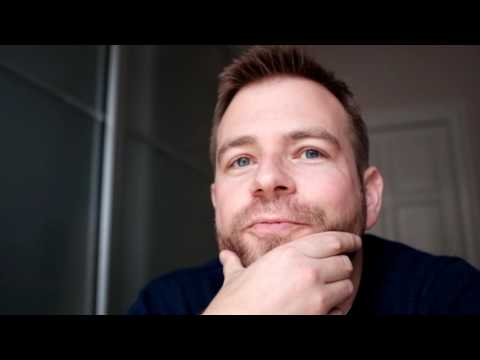

In [14]:
YouTubeVideo("wkYvdfkVmlI",width=800, height=450)

# direct youtube link: https://www.youtube.com/watch?v=wkYvdfkVmlI

_Exercise_: Comparing in the different genres. 

*Setup*. You'll need to go to your archives and find the wikipedia pages of all the rock artists. 

Once you have the texts ready, you will want to aggregate the text into 15 long lists, one for each of the top 15 genres (let's call them 15 *documents*). Each document contains on all the text in that genre (so for the rock genre it's a looooong big doc). In each list, you should keep all the words (or *tokens* to be more precise) that occur on the pages, and a count of how frequently each word occurs. So the format should be

```
word0 count0
word1 count1
word2 count2

...

wordN countN
```
This list is called a ***Term Frequency*** (or TF) list for each genre. Let's build our own TF lists. Before you start counting, I am going to ask you do do a few things

> *Action items*
> * Tokenize the pages into one long string per genre
> * Remove all punctuation from your list of tokens
> * Set everything to lower case
> * (Optional) Lemmatize your words
> * It's a good idea to filter out rare words (e.g. words that only appear less than 5 times).

If you are confused by the instructions for cleaning, go back and have a look at Chapter 3 again. You need to use the tools from the book to clean the text.

> *Action item*: 
> * Create your TF list for each of the 15 most popular genres.
> * List the top 15 words for each genre.
> * Comment on the top 15 words for each genre.

**Note**: Above you (once again) have to deal with the fact that many artists have multiple genres listed. Pick the method you like the best to deal with this. Some possible choices
* Counting each page multiple times, so a page counts once per genre that's listed
* Picking the first genre listed
* Picking the second genre listed
* Picking a random genre
* (... any other heuristic you like, e.g. using an api to ask an LLM to pick the genre that best describes the page from its list)

<div class="alert alert-block alert-info">
It's OK to use an LLM to help with the code here, but write your own comments.
</div>

In [1]:
import json
import string
from pathlib import Path
from collections import Counter, defaultdict

# Load genre data
with open('data/artist_genres.json', 'r') as f:
    artist_genres = json.load(f)

# Get top 15 genres
all_genres = []
for genres in artist_genres.values():
    all_genres.extend(genres)
top_15_genres = [g for g, _ in Counter(all_genres).most_common(15)]

# Aggregate texts by genre (each artist's text counts for all their genres)
genre_texts = defaultdict(list)
pages_dir = Path('data/performer_pages')

for artist_name, genres in artist_genres.items():
    file_path = pages_dir / f"{artist_name}.txt"
    if file_path.exists():
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
        for genre in genres:
            if genre in top_15_genres:
                genre_texts[genre].append(text)

# Clean and tokenize
def clean_and_tokenize(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.split()

# Count terms for each genre
tf_counts = {}
for genre, texts in genre_texts.items():
    tokens = []
    for text in texts:
        tokens.extend(clean_and_tokenize(text))
    counts = Counter(tokens)
    # Filter rare words (< 5 occurrences)
    tf_counts[genre] = Counter({w: c for w, c in counts.items() if c >= 5})

# Print top 15 words per genre
for genre in top_15_genres:
    print(f"\nTop 15 words in genre '{genre}':")
    for word, cnt in tf_counts[genre].most_common(15):
        print(f"  {word}: {cnt}")



Top 15 words in genre 'hard rock':
  the: 54099
  and: 24578
  in: 23029
  of: 21639
  to: 15667
  a: 15615
  on: 13588
  was: 10084
  with: 9334
  band: 8507
  for: 8419
  album: 7642
  rock: 5956
  as: 5830
  at: 5774

Top 15 words in genre 'alternative rock':
  the: 58713
  and: 24806
  in: 22233
  of: 21730
  a: 16227
  to: 15335
  on: 14646
  for: 9869
  was: 9654
  with: 8995
  album: 8778
  band: 8646
  as: 6073
  at: 6070
  that: 5882

Top 15 words in genre 'pop rock':
  the: 44841
  and: 18860
  in: 17899
  of: 16407
  a: 12698
  to: 11688
  on: 10653
  was: 7544
  for: 7460
  with: 6875
  album: 6182
  band: 5738
  at: 5020
  as: 4539
  by: 3880

Top 15 words in genre 'rock':
  the: 49448
  and: 22659
  of: 20460
  in: 20313
  a: 15108
  to: 13562
  on: 9731
  was: 8200
  with: 7527
  for: 7219
  his: 5565
  as: 5359
  at: 5330
  album: 4831
  he: 4831

Top 15 words in genre 'alternative metal':
  the: 23433
  and: 10031
  of: 9800
  in: 9101
  a: 7039
  to: 7011
  on: 6654


# Part 4: Visualization

**Step 1: Install the software**

First you must set up your system. The most difficult thing about creating the wordcloud is installing the `WordCloud` module. It's available on GitHub, check out the page [**here**](https://github.com/amueller/word_cloud). 

You should be able to simply install using conda (and all dependencies, etc will be automatically fixed): 

    conda install -c conda-forge wordcloud
 
If you can't get that to work, there is more info on the GitHub page
 * On my system, the module needed the `gcc` compiler installed. If you're not already a programmer, you may have to install that. On Mac you get it by installing the [_command line tools_](http://osxdaily.com/2014/02/12/install-command-line-tools-mac-os-x/). On linux, it's probably already installed. And on Windows I'm not sure, but we'll figure it out during the exercises. 
 * Once that's all set up, you can use `pip` to install the `WordCloud` library, as [detailed on the GitHub page](https://github.com/amueller/word_cloud). But don't forget to use Anaconda's `pip`.
 * There are examples of how to use the module online, see [this page](http://sebastianraschka.com/Articles/2014_twitter_wordcloud.html) for a nice example. If you're interested, you can read about how the package was put together - and how it works [here](http://peekaboo-vision.blogspot.dk/2012/11/a-wordcloud-in-python.html). 

**Step 2: Draw some wordclouds**

> *Action items*
> * Get your lists ready for the word-cloud software
>    - The package needs a single string to work on. The way that I converted my lists to a string was to simply combine all words together in one long string (separated by spaces), repeating each word according to its count. 
>    - The `wordcloud` package looks for collocations in real texts, which is a problem when you make the list as above. The recommended fix is to simply set `collocations = False` as an option when you run the package.
> * Now, create a word-cloud for each genre. Feel free to make it as fancy or non-fancy as you like. Comment on the results. (If you'd like, you can remove stopwords and wiki-syntax - I did a bit of that for my own wordclouds.)

<div class="alert alert-block alert-info">
As above, it's OK to use an LLM to help get the code going. But write your own answers to the questions.
</div>

  Using cached wordcloud-1.9.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.4 kB)
Using cached wordcloud-1.9.4-cp312-cp312-macosx_11_0_arm64.whl (168 kB)


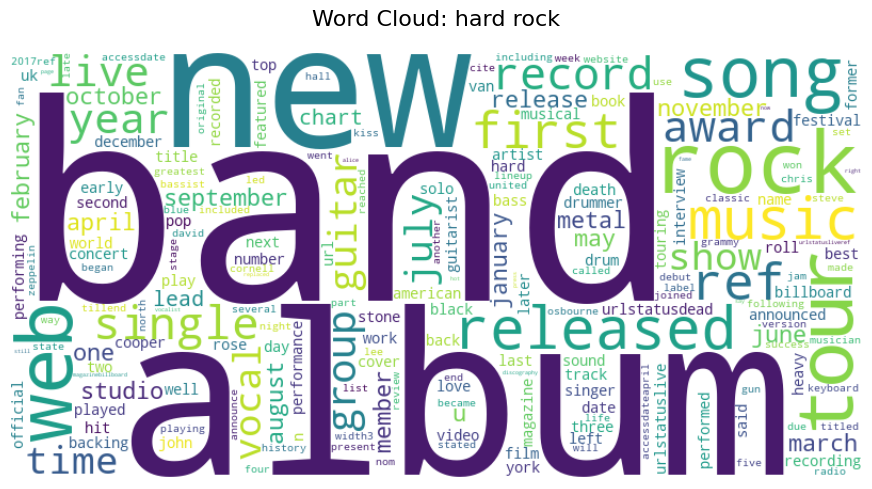

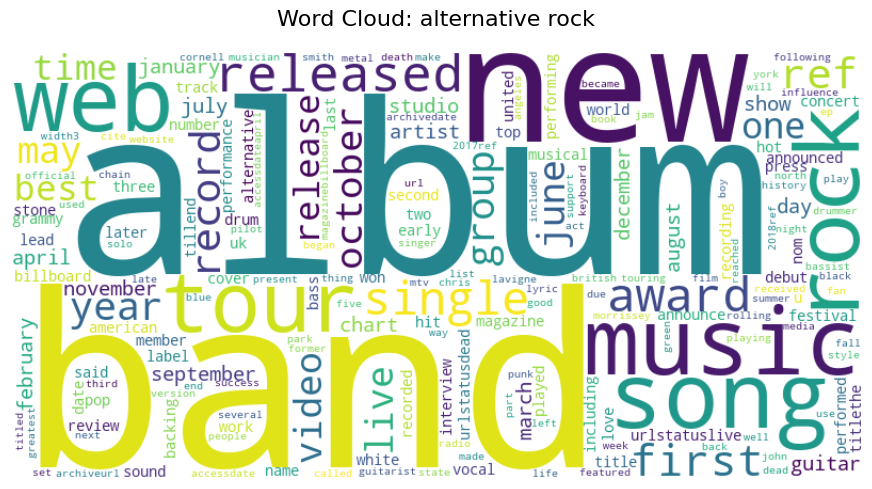

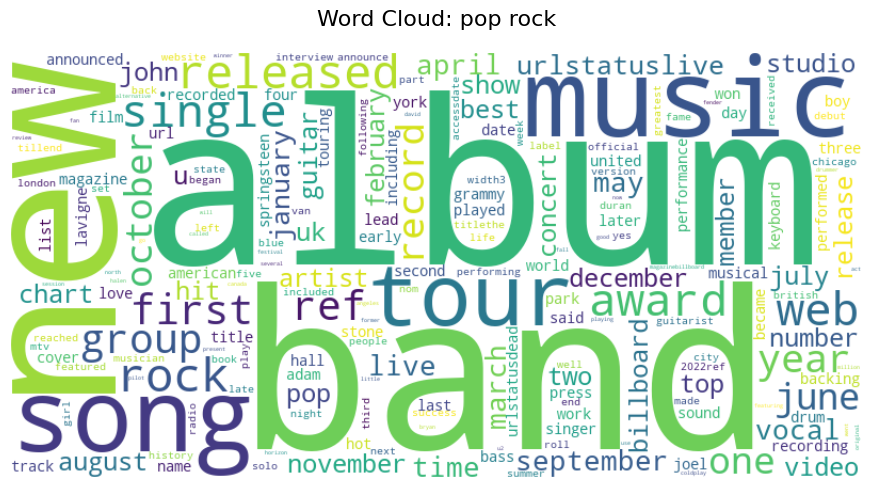

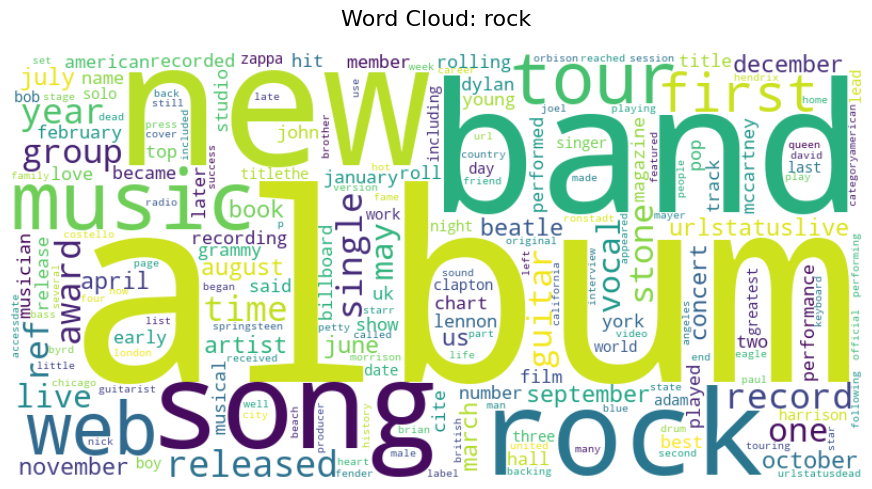

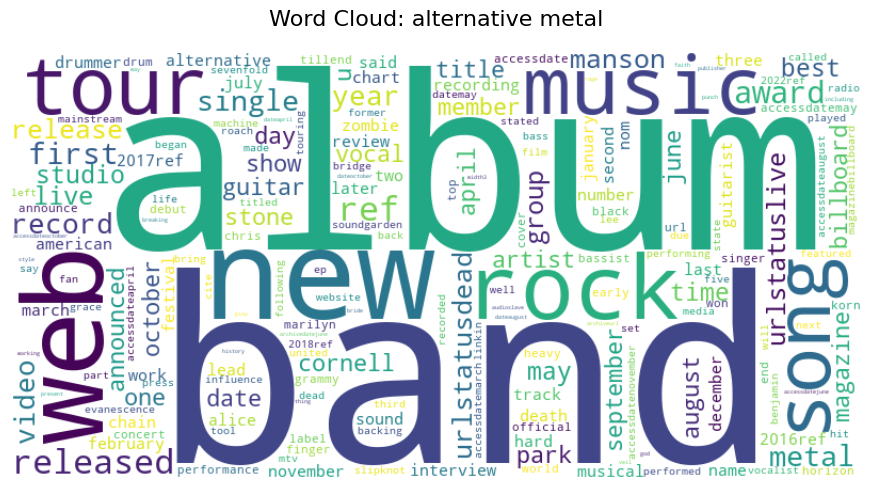

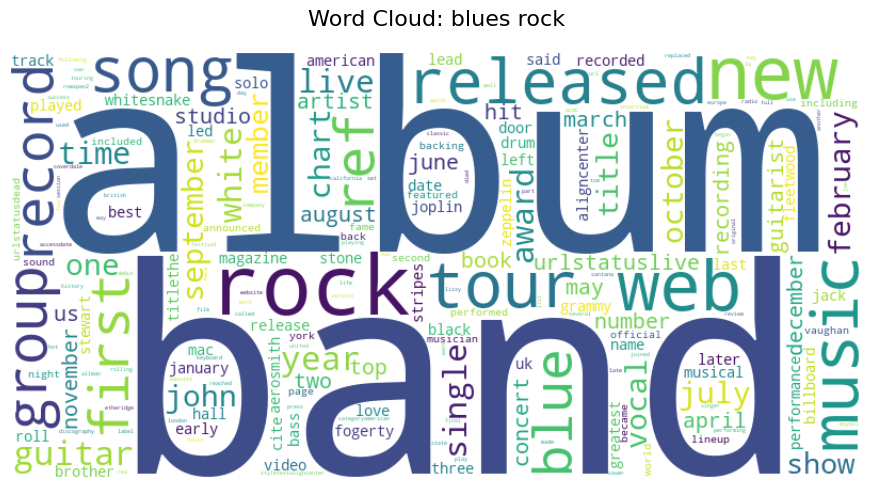

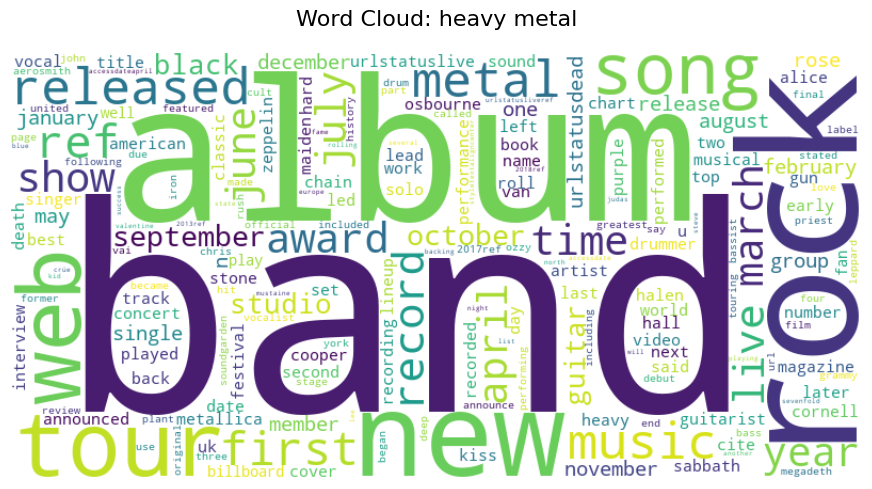

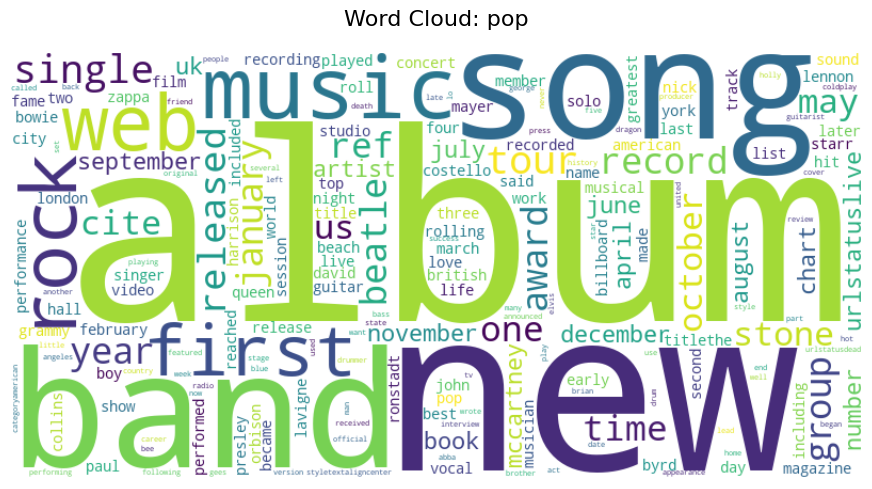

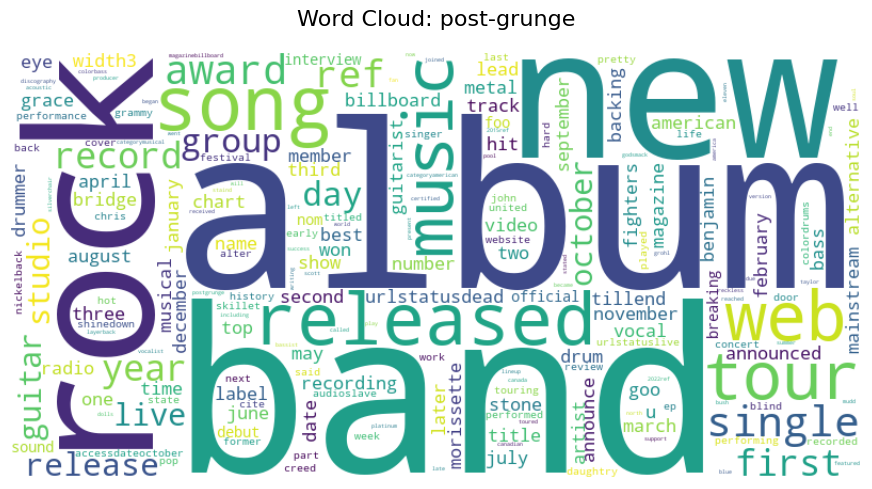

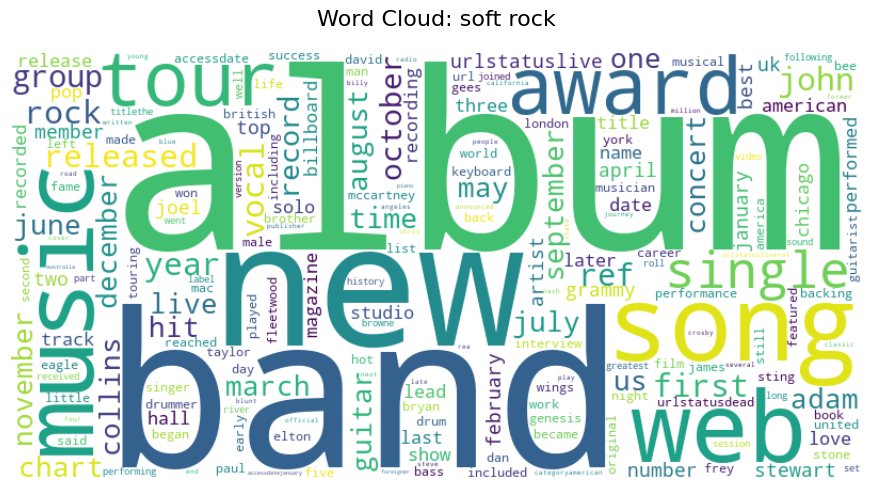

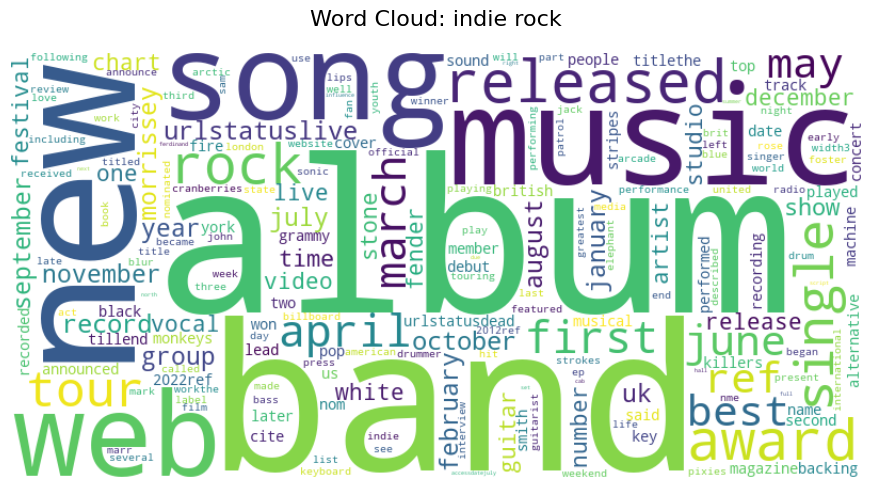

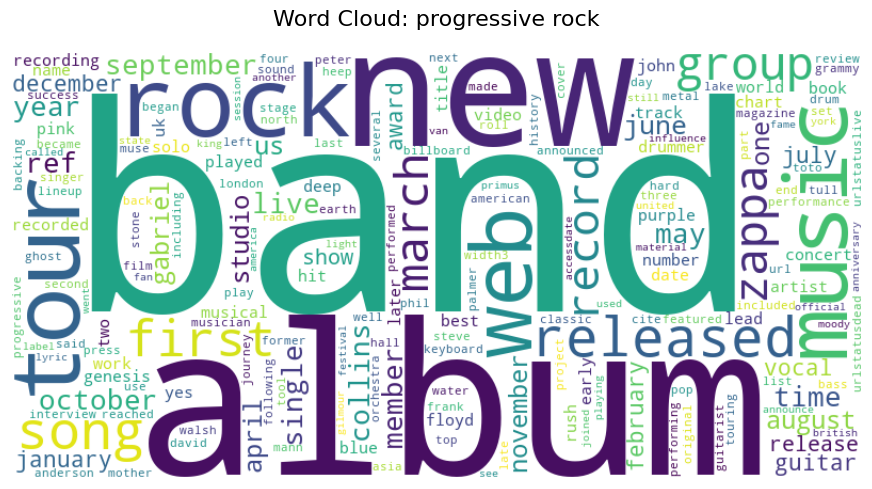

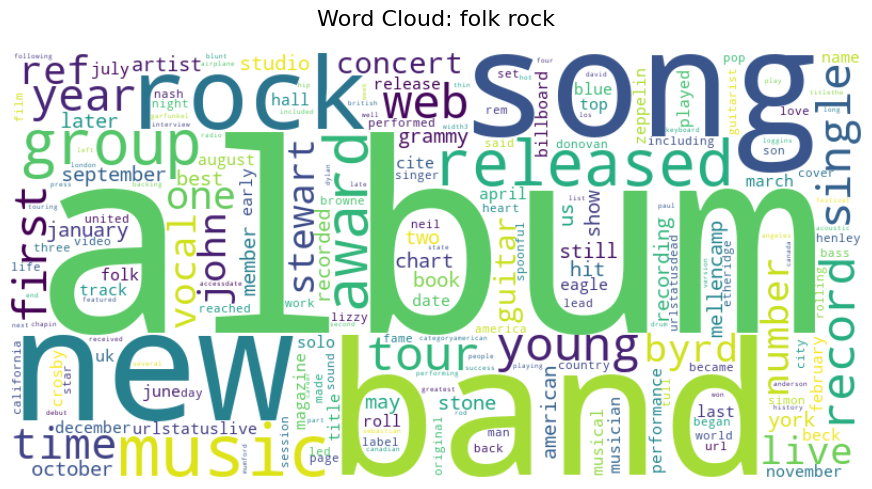

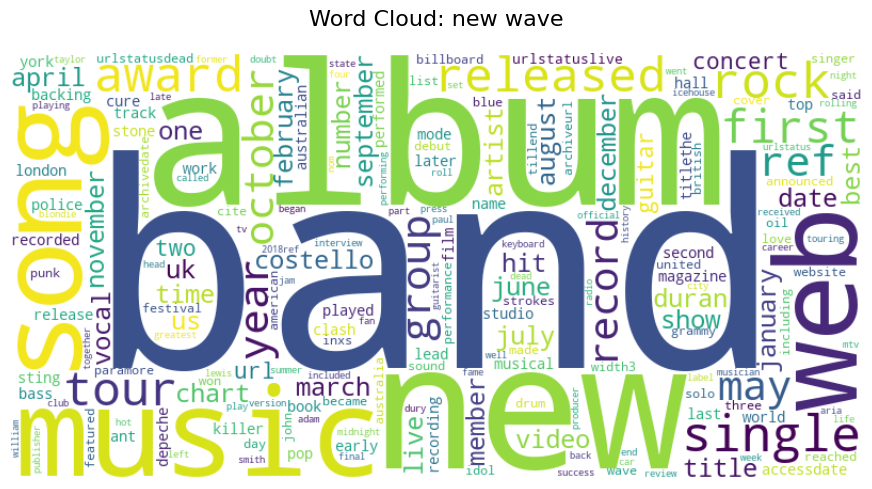

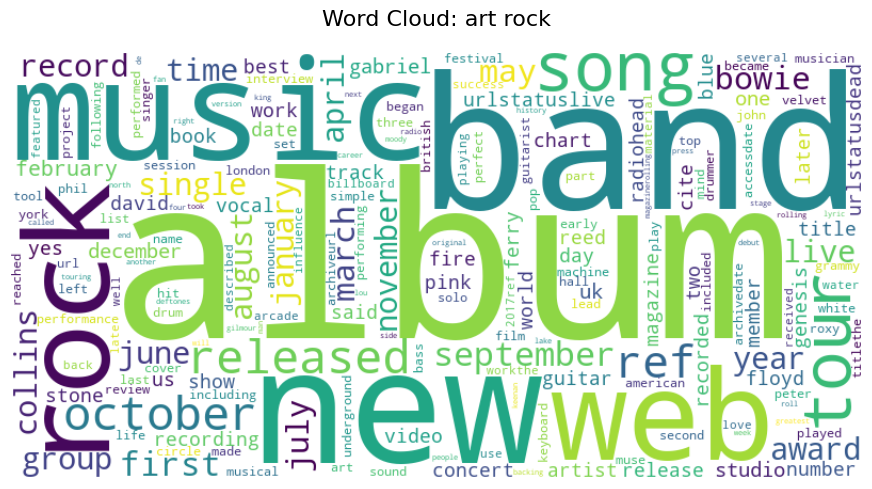

In [3]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create wordcloud for each genre using TF counts
for genre in top_15_genres:
    if genre in tf_counts:
        # Convert word counts to string (repeat each word by its count)
        text_string = ' '.join(word for word, count in tf_counts[genre].items() 
                              for _ in range(count))
        
        # Generate wordcloud
        wordcloud = WordCloud(width=800, height=400, 
                            background_color='white',
                            collocations=False).generate(text_string)
        
        # Display
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud: {genre}', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

# Part 5: Understanding TF-IDF

Now we jump back into the NLP work. In this last part, we'll be creating word-clouds again. But this time, we'll be using the method from the paper I discuss above: TF-IDF. Historically people have had a hard time grasping the idea behind TF-IDF, so here's a little exercise designed to make you study it a bit more carefully.

*Exercise 4*: Wrap your brain around TF-IDF

First, let's learn about TF-IDF the way wikipedia explains it. Check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) and ***read the first part very carefully***. The idea is that the term frequency doesn't capture just what's special about a text. It also only captures words that are just frequent in all text. 

This is clear from the top counts in one of my lists:

```
of 
in 
and 
the 
to 
a 
is
by
was
as
ref
with
first
 ```
 
You can fix some of this by removing stop-words (as is described in the book), but it's not enough. ***We want to pull out what's special about a particular text.*** 

To focus on just what's special, TF-IDF has two components: The *term frequency* (TF) and a *weight* (IDF). The weight draws on a larger corpus of text emphasize what's special about the text we're interested in.

Further, there are some extra things going on. For example, there are multiple definitions of TF on wikipedia. Above, we just looked at the raw counts.

> *Action item*
>   * Pick one of the alternative term frequency definitions. Explain why it might sometimes be prefereable to the raw count.

Now, let's talk about the inverse document frequency.

> *Action item*
>   * What does IDF stand for? Answer in your own words.
>   * How does IDF draw on a larger corpus to extract what's special a certain text? Answer in your own words.

There are also multiple versions of IDF. Let's think about those for a moment.

> *Action items*
>   * All of the IDF versions take the log of the calculated weight. Why do you think that is?
>   * Explain why using IDF makes stopword removal less important.

<div class="alert alert-block alert-info">
The point of this exercise is to understand TF-IDF. So if there are parts of the wikipedia page you don't understand, I encourage you to ask questions to an LLM to really understand the concept. Perhaps ask it to explain TF-IDF at the level of a high-school student. Once you've done that, then answer the questions in the action items on your own.
</div>

# Part 6: Genres and TF-IDF word-clouds

**But wait a minute!** Now we have all of the ingredients for a wonderful cocktail 😎

* We have genres - descriptions of related nodes in the network. 
* And you're an expert on TF-IDF, so you can extract words that characterize a text relative to everything that's going on.
* Finally, you can create nice WordCouds!

So let's put it all together. Let's use TF-IDF and wordcoulds to build a deeper understanding of the top communities.

Thus, the aim of this final part is to create genre wordclouds for the top 15 genres based on TF-IDF. 

For each genre, create a single document for each community consisting of all the cleaned text from all members of the community. So in the end, you should have 15 documents in total.

_Exercise_: Genre Word-clouds

> * Now that we have the community-texts, let's start by grabbing the TF lists from the exercise above (you may modify to use whichever version of TF you like). 
> * Next, calculate IDF for every word in every list (use whichever version of IDF you like). 
>   * Which base logarithm did you use? Is that important?
> * We're now ready to calculate TF-IDFs. Do that for each genre. 
>   * List the 10 top words for each genre accourding to TF-IDF. Are these 10 words more descriptive of the genre than just the TF? Justify your answer.
> * Create a wordcloud for each genre.
>     * **Note**: you may have to rescale the TF-IDF weights so they make sense to the wordcloud package. Write about this issue and how you solve it.
> * Explain your creation. Do the wordclouds/TF-IDF lists enable you to understand the communities you have found (or is it just gibberish)? Justify your answer.

<div class="alert alert-block alert-info">
Overall, it's OK to use an LLM to help with the code. But do write your own answers to the questions.
</div>

*Exercise*: Community Word-clouds
> * Redo the exercise above but for the 15 largest structural communities.
> * Do the word clouds seem more meaningful than for the genres? Optional: Add nuance to your answer by considering the confusion matrix $D$ that you calculated above.

Note that this is a great way of characterizing the structural communities if you don't have genre-labels (or other labels for that matter).

<div class="alert alert-block alert-info">
Todays exercices are getting, long and involved so you can do whatever parts of this one that you like with LLMs. Maybe you can even get one to solve the whole exercise?
</div>